<a href="https://colab.research.google.com/github/RytisBalt/Finansinis-intelektas/blob/FinansinisIntelektas2/Finansinis2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import yfinance as yf
import datetime
import pandas as pd
import numpy as np

heineken_df = pd.read_csv('/content/HEIA.AS.csv', delimiter=',')
bp_df = pd.read_csv('/content/BP_duomenys.csv', delimiter=',')

heineken_df['Date'] = pd.to_datetime(heineken_df['Date'])
bp_df['Date'] = pd.to_datetime(bp_df['Date'])
print(heineken_df)
print(bp_df)

          Date       Open       High        Low      Close  Adj Close  Volume
0   2023-03-27  98.099998  98.820000  97.599998  97.599998  95.685829  716418
1   2023-03-28  97.779999  97.919998  95.940002  96.699997  94.803482  587277
2   2023-03-29  96.760002  98.580002  96.760002  98.440002  96.509361  524812
3   2023-03-30  98.599998  98.820000  97.360001  97.580002  95.666229  518694
4   2023-03-31  97.680000  99.599998  97.660004  99.059998  97.117203  643776
..         ...        ...        ...        ...        ...        ...     ...
250 2024-03-19  84.260002  84.720001  83.919998  84.620003  84.620003  495701
251 2024-03-20  84.400002  84.660004  84.120003  84.199997  84.199997  377925
252 2024-03-21  84.739998  84.900002  84.059998  84.320000  84.320000  440729
253 2024-03-22  84.199997  86.779999  84.139999  86.379997  86.379997  550833
254 2024-03-25  86.540001  86.879997  86.120003  86.599998  86.599998  351387

[255 rows x 7 columns]
          Date       Open       High    

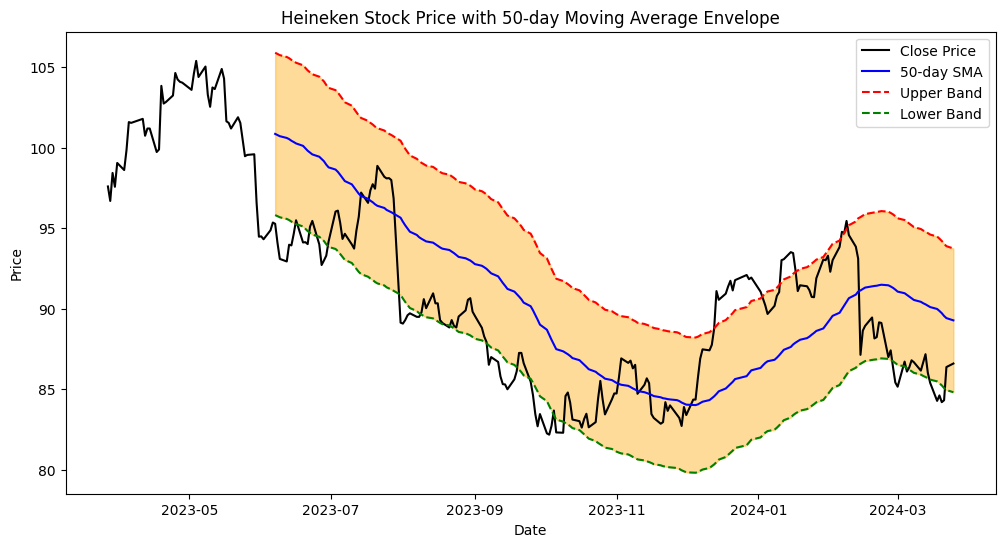

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


heineken_df['50_SMA'] = heineken_df['Close'].rolling(window=50).mean()

envelope_percentage = 0.05
heineken_df['Upper_band'] = heineken_df['50_SMA'] + envelope_percentage * heineken_df['50_SMA']
heineken_df['Lower_band'] = heineken_df['50_SMA'] - envelope_percentage * heineken_df['50_SMA']

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(heineken_df['Date'], heineken_df['Close'], label='Close Price', color='black')
plt.plot(heineken_df['Date'], heineken_df['50_SMA'], label='50-day SMA', color='blue')
plt.plot(heineken_df['Date'], heineken_df['Upper_band'], label='Upper Band', linestyle='--', color='red')
plt.plot(heineken_df['Date'], heineken_df['Lower_band'], label='Lower Band', linestyle='--', color='green')
plt.fill_between(heineken_df['Date'], heineken_df['Lower_band'], heineken_df['Upper_band'], color='orange', alpha=0.4)
plt.title('Heineken Stock Price with 50-day Moving Average Envelope')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()


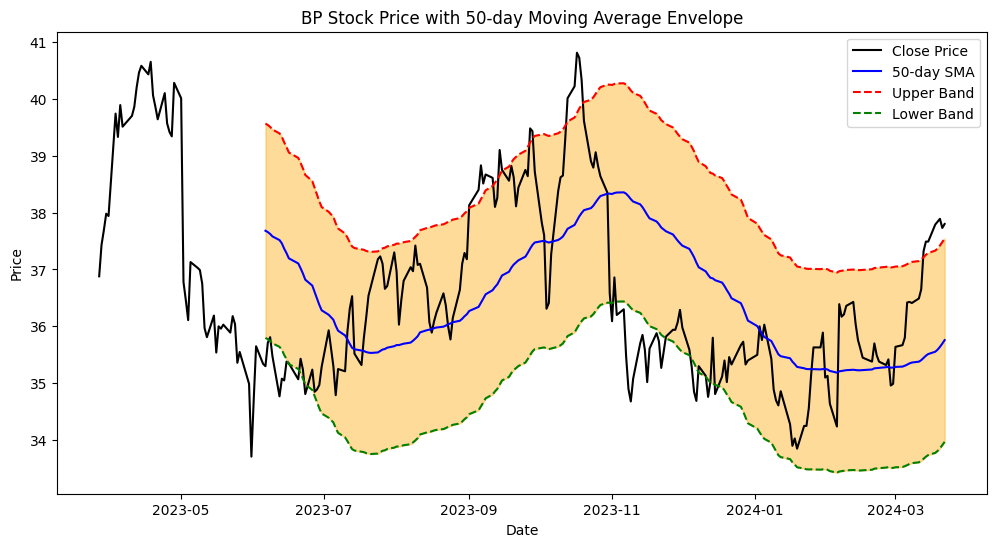

In [ ]:
bp_df['50_SMA'] = bp_df['Close'].rolling(window=50).mean()

envelope_percentage = 0.05
bp_df['Upper_band'] = bp_df['50_SMA'] + envelope_percentage * bp_df['50_SMA']
bp_df['Lower_band'] = bp_df['50_SMA'] - envelope_percentage * bp_df['50_SMA']

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(bp_df['Date'], bp_df['Close'], label='Close Price', color='black')
plt.plot(bp_df['Date'], bp_df['50_SMA'], label='50-day SMA', color='blue')
plt.plot(bp_df['Date'], bp_df['Upper_band'], label='Upper Band', linestyle='--', color='red')
plt.plot(bp_df['Date'], bp_df['Lower_band'], label='Lower Band', linestyle='--', color='green')
plt.fill_between(bp_df['Date'], bp_df['Lower_band'], bp_df['Upper_band'], color='orange', alpha=0.4)
plt.title('BP Stock Price with 50-day Moving Average Envelope')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()


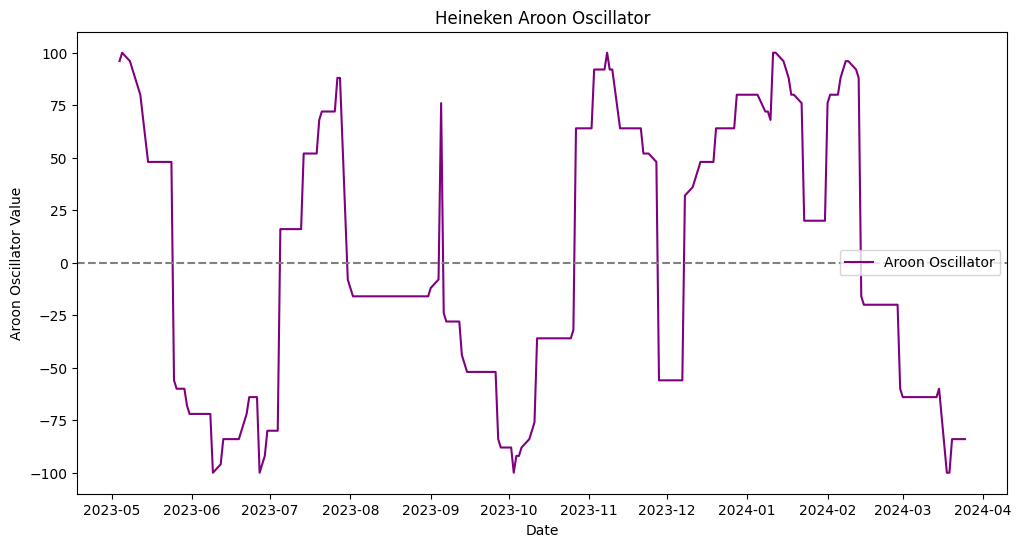

In [ ]:
import pandas as pd
import numpy as np

def aroon_oscillator(df, period=25):
    df['Aroon_Up'] = 100 * df['High'].rolling(window=period + 1).apply(lambda x: x.argmax()) / period
    df['Aroon_Down'] = 100 * df['Low'].rolling(window=period + 1).apply(lambda x: x.argmin()) / period
    df['Aroon_Oscillator'] = df['Aroon_Up'] - df['Aroon_Down']
    return df


heineken_df = aroon_oscillator(heineken_df)
plt.figure(figsize=(12, 6))
plt.plot(heineken_df['Date'], heineken_df['Aroon_Oscillator'], label='Aroon Oscillator', color='purple')
plt.axhline(y=0, color='gray', linestyle='--')
plt.title('Heineken Aroon Oscillator')
plt.xlabel('Date')
plt.ylabel('Aroon Oscillator Value')
plt.legend()
plt.show()


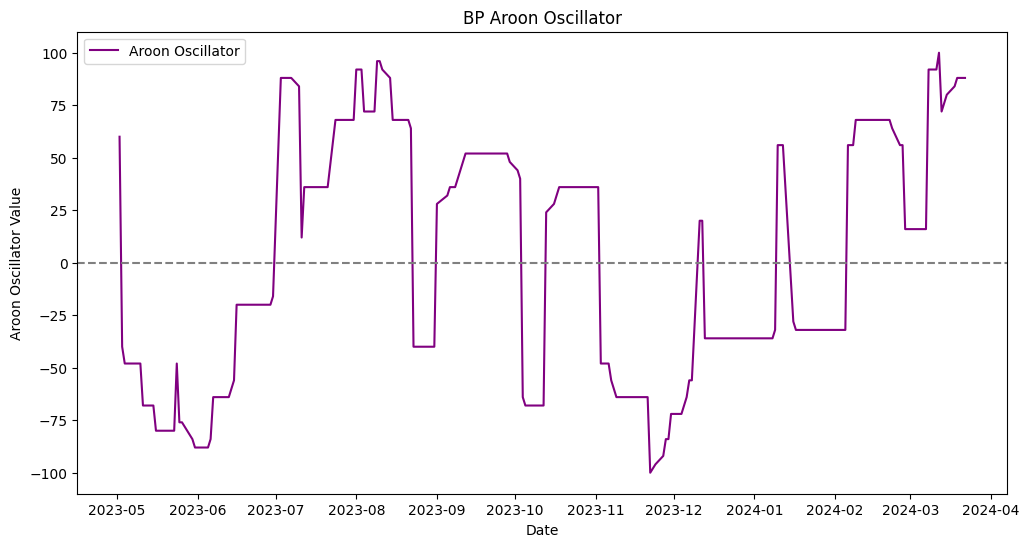

In [ ]:
bp_df = aroon_oscillator(bp_df)

plt.figure(figsize=(12, 6))
plt.plot(bp_df['Date'], bp_df['Aroon_Oscillator'], label='Aroon Oscillator', color='purple')
plt.axhline(y=0, color='gray', linestyle='--')
plt.title('BP Aroon Oscillator')
plt.xlabel('Date')
plt.ylabel('Aroon Oscillator Value')
plt.legend()
plt.show()


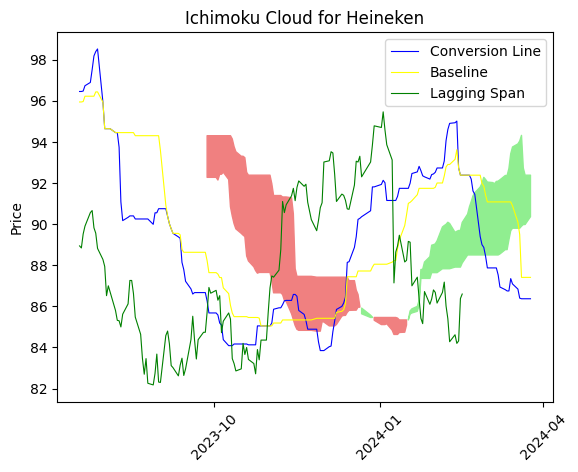

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

high9 = heineken_df.High.rolling(9).max()
low9 = heineken_df.High.rolling(9).min()
high26 = heineken_df.High.rolling(26).max()
low26 = heineken_df.High.rolling(26).min()
high52 = heineken_df.High.rolling(52).max()
low52 = heineken_df.High.rolling(52).min()

heineken_df['tenkan_sen'] = (high9 + low9) / 2
heineken_df["kijun_sen"] = (high26 + low26) / 2
heineken_df["SpanA"] = ((heineken_df.tenkan_sen + heineken_df.kijun_sen) / 2).shift(26)
heineken_df["SpanB"] = ((high52 + low52) / 2).shift(26)
heineken_df["chikou"] = heineken_df.Close.shift(-26)
heineken_df = heineken_df.iloc[26:]

plt.plot(heineken_df['Date'], heineken_df['tenkan_sen'], lw=0.8, color="blue", label="Conversion Line")
plt.plot(heineken_df['Date'], heineken_df['kijun_sen'], lw=0.8, color="yellow", label="Baseline")
plt.plot(heineken_df['Date'], heineken_df['chikou'], lw=0.8, color="green", label="Lagging Span")
plt.fill_between(heineken_df['Date'], heineken_df['SpanA'], heineken_df['SpanB'], where=heineken_df['SpanA'] >= heineken_df['SpanB'], color="lightgreen")
plt.fill_between(heineken_df['Date'], heineken_df['SpanA'], heineken_df['SpanB'], where=heineken_df['SpanA'] < heineken_df['SpanB'], color="lightcoral")
plt.title("Ichimoku Cloud for Heineken")
plt.ylabel("Price")
plt.legend()


plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45)

plt.show()


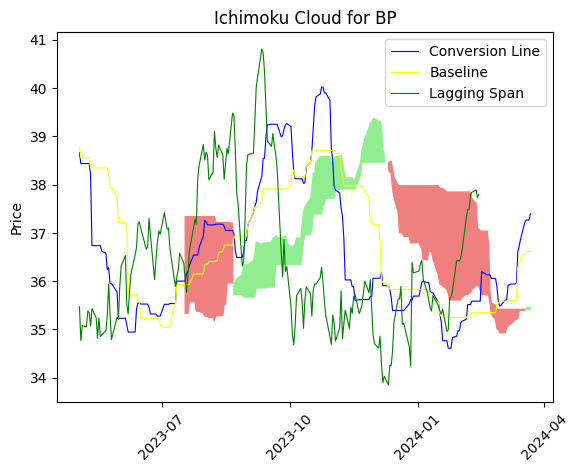

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


high9 = bp_df.High.rolling(9).max()
low9 = bp_df.High.rolling(9).min()
high26 = bp_df.High.rolling(26).max()
low26 = bp_df.High.rolling(26).min()
high52 = bp_df.High.rolling(52).max()
low52 = bp_df.High.rolling(52).min()


bp_df['tenkan_sen'] = (high9 + low9) / 2
bp_df["kijun_sen"] = (high26 + low26) / 2
bp_df["SpanA"] = ((bp_df.tenkan_sen + bp_df.kijun_sen) / 2).shift(26)
bp_df["SpanB"] = ((high52 + low52) / 2).shift(26)
bp_df["chikou"] = bp_df.Close.shift(-26)
bp_df = bp_df.iloc[26:]

plt.plot(bp_df['Date'], bp_df['tenkan_sen'], lw=0.8, color="blue", label="Conversion Line")
plt.plot(bp_df['Date'], bp_df['kijun_sen'], lw=0.8, color="yellow", label="Baseline")
plt.plot(bp_df['Date'], bp_df['chikou'], lw=0.8, color="green", label="Lagging Span")
plt.fill_between(bp_df['Date'], bp_df['SpanA'], bp_df['SpanB'], where=bp_df['SpanA'] >= bp_df['SpanB'], color="lightgreen" )
plt.fill_between(bp_df['Date'], bp_df['SpanA'], bp_df['SpanB'], where=bp_df['SpanA'] < bp_df['SpanB'], color="lightcoral")
plt.title("Ichimoku Cloud for BP")
plt.ylabel("Price")
plt.legend()


plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45)
plt.show()
